# LSTM Crop Recommendation Model Training & Evaluation

This notebook combines physical-node telemetry from Firebase, simulator telemetry from Supabase, and the labelled historical crop dataset, processes the records into 24-step sequences, applies SMOTE to training windows only, and trains an LSTM (Long Short-Term Memory) neural network to predict the ideal crop.

This serves as the evaluation phase for Chapter 4 of the final year project report.

In [15]:
import os
os.environ.setdefault("KERAS_BACKEND", "torch")

import importlib
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from backend.ml import crop_training_data, firebase_hardware
firebase_hardware = importlib.reload(firebase_hardware)
crop_training_data = importlib.reload(crop_training_data)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, classification_report, f1_score
import keras
from keras import layers, callbacks
import joblib

print("Libraries loaded successfully!")
print("Training data module:", crop_training_data.__file__)

Libraries loaded successfully!
Training data module: /Users/durotoyejoshua/Desktop/2025/FINAL_YEAR_PROJECT/backend/ml/crop_training_data.py


## 1. Data Acquisition from All Three Sources
Fetch every physical reading for `NODE_01` and `NODE_02` from Firebase, every simulator reading for `NODE_03` through `NODE_06` from Supabase, and every labelled row in `pipeline_ready_sensor_data.csv`. The historical file supplies Maize, Rice, Wheat, Potato, Tomato, and Sugarcane examples.

In [16]:
# Load environment variables from .env file
load_dotenv()


print("Loading Firebase, Supabase, and historical crop records...")
data = crop_training_data.fetch_all_crop_training_rows(
    page_size=1000,
    include_historical=True,
)
if not data:
    raise ValueError("No training records were returned from Firebase, Supabase, or the historical dataset.")

print(f"Successfully fetched {len(data):,} total records.")

# Convert to pandas DataFrame for easier exploration
df = pd.DataFrame(data)
raw_timestamps = df['Timestamp'].copy()
df['Timestamp'] = pd.to_datetime(
    raw_timestamps,
    format='mixed',
    utc=True,
    errors='coerce',
)
timestamp_failures = df.loc[df['Timestamp'].isna()].groupby('Data_Source').size().to_dict()
print('Unparseable timestamps by source:', timestamp_failures)

source_summary = (
    df.groupby(['Data_Source', 'Node_ID'])
      .size()
      .rename('Rows')
      .reset_index()
)
display(source_summary)

# Display sample data for Chapter 4.2.1
display(df.head())

Loading Firebase, Supabase, and historical crop records...
Successfully fetched 22,027 total records.
Unparseable timestamps by source: {}


,Data_Source,Node_ID,Rows
0,hardware,NODE_01,62
1,hardware,NODE_02,28
2,historical_csv,HIST_MAIZE,3352
3,historical_csv,HIST_POTATO,3362
4,historical_csv,HIST_RICE,3268
5,historical_csv,HIST_SUGARCANE,3284
6,historical_csv,HIST_TOMATO,3344
7,historical_csv,HIST_WHEAT,3390
8,simulator,NODE_03,485
9,simulator,NODE_04,484


,Timestamp,Temperature_C,Humidity_%,Moisture_%,Nitrogen_mg_k,Phosphorus_m,Potassium_mg_,Soil_pH,Latitude,Longitude,Node_ID,Target_Crop,Data_Source,id,Altitude_m,Satellites,Season,GPS_Source,Device_Uptime_Seconds
0,2024-02-26 16:09:56+00:00,17.261833738526974,72.9416522440957,57.10576971616089,69.0747657352742,53.9544020870548,88.0676247040119,4.631301284674626,8.482483570765057,4.541741431238334,HIST_WHEAT,Wheat,historical_csv,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-02-26 17:09:56+00:00,21.84611565724149,99.36195448548068,54.28131499800797,107.32935206465484,70.10213389904699,32.08106652927613,4.761658350431389,8.479308678494144,4.541416617962678,HIST_TOMATO,Tomato,historical_csv,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-02-26 18:09:56+00:00,33.24689514937074,81.50683564100116,39.97118817635867,130.63462407096128,67.20453317483934,28.29425168407002,6.5660070585641614,8.483238442690505,4.535317400770973,HIST_SUGARCANE,Sugarcane,historical_csv,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-02-26 19:09:56+00:00,14.396288866165008,59.27446469091534,27.3155282867782,15.169301216191364,87.49318129429336,14.336678966117727,6.296296654755076,8.48761514928204,4.5428979211088185,HIST_SUGARCANE,Sugarcane,historical_csv,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-02-26 20:09:56+00:00,16.77321764398873,51.19158384861472,53.58635349248689,21.88196508475118,89.26971210568172,38.833885318797634,8.268274387750605,8.478829233126383,4.532549586622117,HIST_MAIZE,Maize,historical_csv,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Target Label Mapping & Preprocessing
Live node labels come from `backend/ml/crop_node_labels.json`; labelled crops in `pipeline_ready_sensor_data.csv` are included automatically. Invalid sensor values become missing values and are imputed from training data only, so physical records are audited instead of silently deleting an entire crop.

Configured node/crop labels: {'NODE_01': 'Maize', 'NODE_02': 'Maize', 'NODE_03': 'Cassava', 'NODE_04': 'Cassava', 'NODE_05': 'Rice', 'NODE_06': 'Rice'}
Retained 22,027/22,027 labelled records.
Out-of-range values marked for imputation: {'Nitrogen_mg_k': 27, 'Phosphorus_m': 27, 'Potassium_mg_': 27, 'Moisture_%': 0, 'Temperature_C': 0, 'Humidity_%': 20}
Disconnected NPK rows marked for imputation: 56


,Data_Source,Target_Crop,Node_ID,Rows
0,hardware,Maize,NODE_01,62
1,hardware,Maize,NODE_02,28
2,historical_csv,Maize,HIST_MAIZE,3352
3,historical_csv,Potato,HIST_POTATO,3362
4,historical_csv,Rice,HIST_RICE,3268
5,historical_csv,Sugarcane,HIST_SUGARCANE,3284
6,historical_csv,Tomato,HIST_TOMATO,3344
7,historical_csv,Wheat,HIST_WHEAT,3390
8,simulator,Cassava,NODE_03,485
9,simulator,Cassava,NODE_04,484


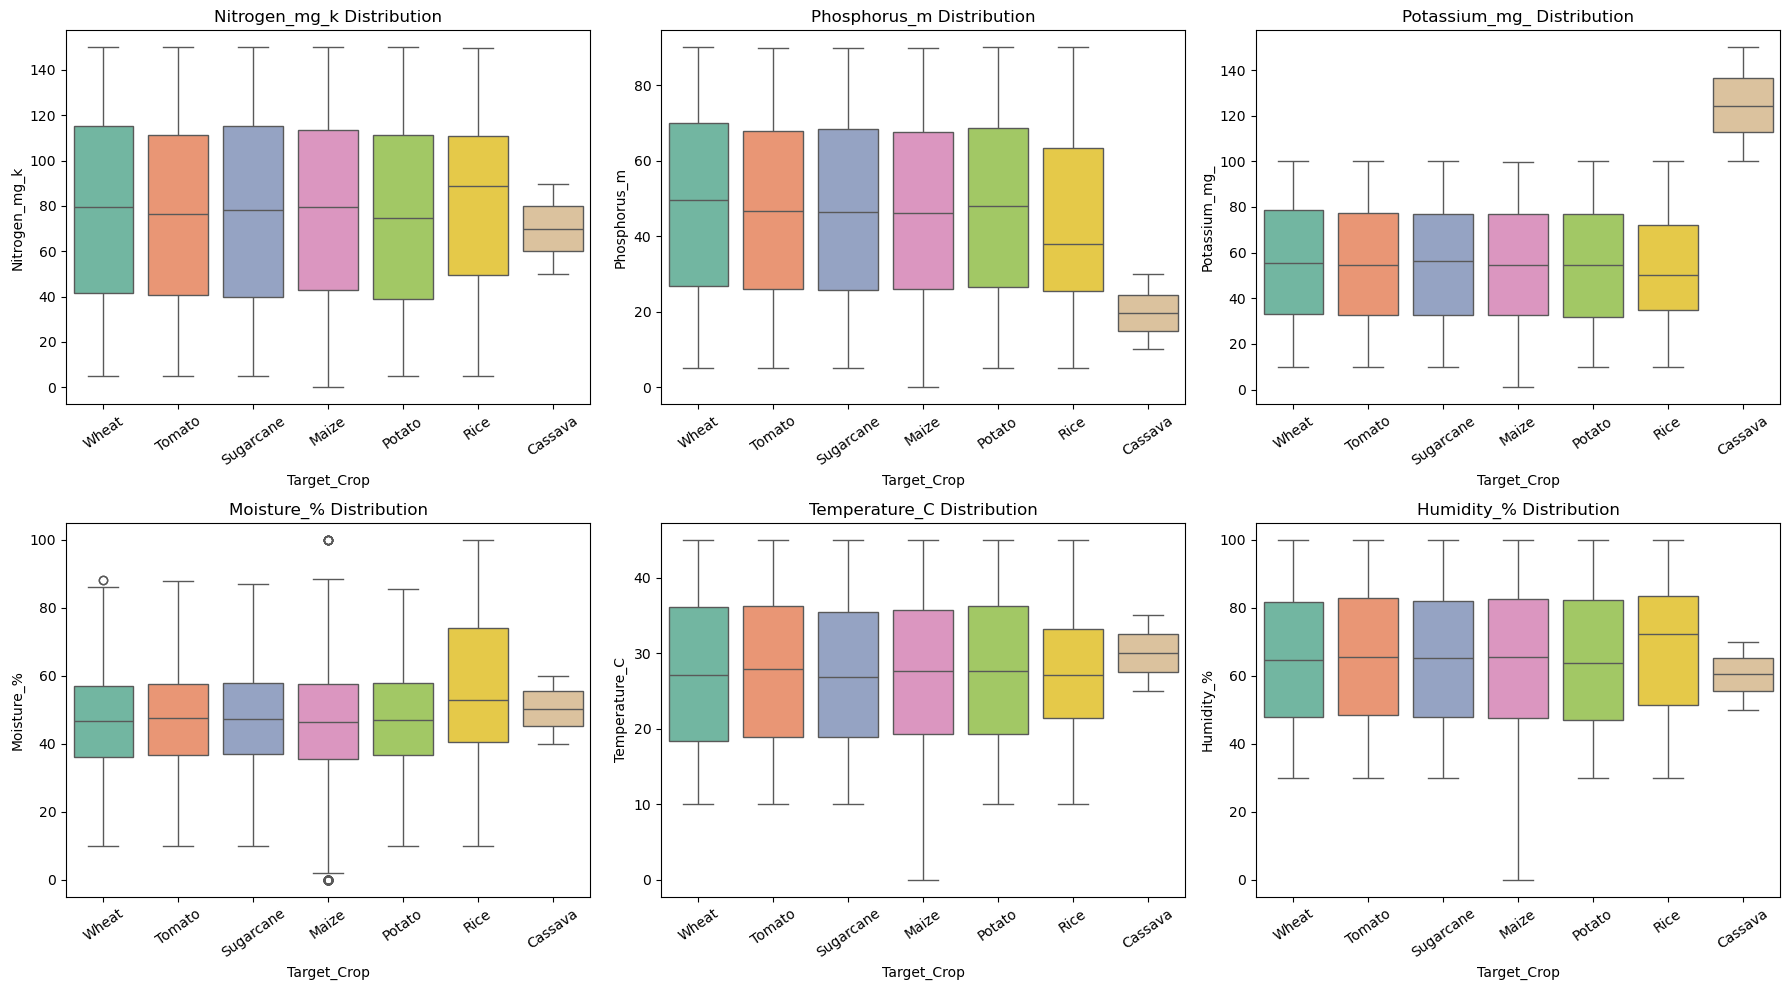

In [17]:
NODE_CROP_MAP = crop_training_data.load_node_crop_map()
print("Configured node/crop labels:", NODE_CROP_MAP)

features_to_plot = ["Nitrogen_mg_k", "Phosphorus_m", "Potassium_mg_", "Moisture_%", "Temperature_C", "Humidity_%"]
feature_bounds = {
    'Nitrogen_mg_k': (0, 200),
    'Phosphorus_m': (0, 200),
    'Potassium_mg_': (0, 250),
    'Moisture_%': (0, 100),
    'Temperature_C': (-10, 60),
    'Humidity_%': (0, 100),
}

# Keep every labelled record, but mark impossible sensor values as missing.
# They will be imputed after splitting, using training data only.
invalid_counts = {}
for feature in features_to_plot:
    df[feature] = pd.to_numeric(df[feature], errors='coerce')
    lower, upper = feature_bounds[feature]
    invalid = df[feature].notna() & ~df[feature].between(lower, upper)
    invalid_counts[feature] = int(invalid.sum())
    df.loc[invalid, feature] = np.nan

# The gateway treats simultaneous 0/0/0 NPK as a disconnected sensor.
npk_features = ['Nitrogen_mg_k', 'Phosphorus_m', 'Potassium_mg_']
npk_disconnected = df[npk_features].eq(0).all(axis=1)
df.loc[npk_disconnected, npk_features] = np.nan

rows_before_validation = len(df)
df = df.dropna(subset=['Timestamp', 'Target_Crop']).copy()
configured_crops = set(NODE_CROP_MAP.values())
available_crops = set(df['Target_Crop'].unique())
missing_configured_crops = configured_crops - available_crops
if missing_configured_crops:
    raise ValueError(f'Configured crops have no extracted rows: {sorted(missing_configured_crops)}')

print(f"Retained {len(df):,}/{rows_before_validation:,} labelled records.")
print('Out-of-range values marked for imputation:', invalid_counts)
print('Disconnected NPK rows marked for imputation:', int(npk_disconnected.sum()))
label_audit = (
    df.groupby(['Data_Source', 'Target_Crop', 'Node_ID'])
      .size().rename('Rows').reset_index()
)
display(label_audit)

# Plot the distribution of valid measured values across every crop.
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, feature in enumerate(features_to_plot):
    row, col = i // 3, i % 3
    sns.boxplot(data=df, x='Target_Crop', y=feature, hue='Target_Crop', ax=axes[row, col], palette='Set2', legend=False)
    axes[row, col].set_title(f'{feature} Distribution')
    axes[row, col].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.savefig('feature_distribution.png', dpi=300)
plt.show()

## 3. Sequence Generation for LSTM
LSTMs require 3D input arrays: `(samples, time_steps, features)`. Nodes and time ranges are separated before scaling and window generation so overlapping observations cannot leak into validation or test results. SMOTE is applied only to the training windows; validation and test windows remain real measurements.

In [18]:
SEQUENCE_LENGTH = 24
FEATURES = features_to_plot
RANDOM_STATE = 42
keras.utils.set_random_seed(RANDOM_STATE)

label_encoder = LabelEncoder()
df['Crop_Label'] = label_encoder.fit_transform(df['Target_Crop'])

# Keep complete nodes apart where a crop has multiple nodes. The smaller node
# becomes the independent test node; remaining nodes are split chronologically
# into training and validation periods. A one-node crop is split by time.
segments = {'train': [], 'validation': [], 'test': []}

def add_segment(split_name, node_frame):
    if len(node_frame) >= SEQUENCE_LENGTH:
        segments[split_name].append(node_frame.copy())

for crop_name, crop_frame in df.groupby('Target_Crop'):
    node_frames = [
        node_frame.sort_values('Timestamp').reset_index(drop=True)
        for _, node_frame in crop_frame.groupby('Node_ID')
        if len(node_frame) >= SEQUENCE_LENGTH
    ]
    node_frames.sort(key=len, reverse=True)
    if not node_frames:
        raise ValueError(f'{crop_name} needs at least {SEQUENCE_LENGTH} complete readings.')

    if len(node_frames) > 1:
        add_segment('test', node_frames[-1])
        training_nodes = node_frames[:-1]
    else:
        only_node = node_frames[0]
        if len(only_node) >= 3 * SEQUENCE_LENGTH:
            test_size = max(SEQUENCE_LENGTH, int(np.ceil(len(only_node) * 0.15)))
            add_segment('test', only_node.iloc[-test_size:])
            training_nodes = [only_node.iloc[:-test_size]]
        elif len(only_node) >= 2 * SEQUENCE_LENGTH:
            add_segment('test', only_node.iloc[-SEQUENCE_LENGTH:])
            training_nodes = [only_node.iloc[:-SEQUENCE_LENGTH]]
        else:
            training_nodes = [only_node]

    for node_frame in training_nodes:
        validation_size = max(SEQUENCE_LENGTH, int(np.ceil(len(node_frame) * 0.15)))
        if len(node_frame) - validation_size >= SEQUENCE_LENGTH:
            add_segment('train', node_frame.iloc[:-validation_size])
            add_segment('validation', node_frame.iloc[-validation_size:])
        else:
            add_segment('train', node_frame)

if not segments['train'] or not segments['test']:
    raise ValueError('Not enough readings to create leakage-free training and test windows.')

# Fit imputation and scaling on real training observations only.
imputer = SimpleImputer(strategy='median')
training_features = pd.concat(segments['train'], ignore_index=True)[FEATURES]
imputed_training_features = imputer.fit_transform(training_features)
scaler = MinMaxScaler()
scaler.fit(imputed_training_features)

def make_sequences(node_segments):
    X_list, y_list = [], []
    for node_frame in node_segments:
        imputed_features = imputer.transform(node_frame[FEATURES])
        feature_data = scaler.transform(imputed_features)
        label_data = node_frame['Crop_Label'].to_numpy(dtype=np.int64)
        for start in range(len(node_frame) - SEQUENCE_LENGTH + 1):
            stop = start + SEQUENCE_LENGTH
            X_list.append(feature_data[start:stop])
            y_list.append(label_data[stop - 1])
    return np.asarray(X_list, dtype=np.float32), np.asarray(y_list, dtype=np.int64)

X_train, y_train = make_sequences(segments['train'])
X_validation, y_validation = make_sequences(segments['validation'])
X_test, y_test = make_sequences(segments['test'])

expected_labels = set(range(len(label_encoder.classes_)))
for split_name, split_labels in [('training', y_train), ('validation', y_validation), ('test', y_test)]:
    missing = expected_labels - set(np.unique(split_labels))
    if missing:
        names = [label_encoder.classes_[label] for label in sorted(missing)]
        raise ValueError(f'{split_name.title()} data is missing crops: {names}. Add another node or more readings.')

def crop_counts(labels):
    values, counts = np.unique(labels, return_counts=True)
    return {str(label_encoder.classes_[value]): int(count) for value, count in zip(values, counts)}

print('Real training windows:', crop_counts(y_train))
print('Real validation windows:', crop_counts(y_validation))
print('Real test windows:', crop_counts(y_test))

Real training windows: {'Cassava': 389, 'Maize': 2841, 'Potato': 2405, 'Rice': 3142, 'Sugarcane': 2349, 'Tomato': 2392, 'Wheat': 2425}
Real validation windows: {'Cassava': 50, 'Maize': 481, 'Potato': 406, 'Rice': 518, 'Sugarcane': 396, 'Tomato': 404, 'Wheat': 410}
Real test windows: {'Cassava': 461, 'Maize': 5, 'Potato': 482, 'Rice': 461, 'Sugarcane': 470, 'Tomato': 479, 'Wheat': 486}


## 4. SMOTE Training-Only Augmentation
SMOTE balances minority crops using only training windows. Validation and test sets remain unchanged real observations, and the before/after counts below make the augmentation visible.

In [19]:
minority_count = int(np.unique(y_train, return_counts=True)[1].min())
if minority_count < 2:
    raise ValueError('SMOTE needs at least two real training windows per crop.')

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=min(5, minority_count - 1))
X_train_flat = X_train.reshape(len(X_train), -1)
X_train_balanced_flat, y_train_balanced = smote.fit_resample(X_train_flat, y_train)
X_train_balanced = X_train_balanced_flat.reshape(-1, SEQUENCE_LENGTH, len(FEATURES)).astype(np.float32)

print('BEFORE SMOTE:', crop_counts(y_train))
print('AFTER SMOTE: ', crop_counts(y_train_balanced))
print(f'Real validation windows (unchanged): {len(X_validation):,}')
print(f'Real test windows (unchanged): {len(X_test):,}')

BEFORE SMOTE: {'Cassava': 389, 'Maize': 2841, 'Potato': 2405, 'Rice': 3142, 'Sugarcane': 2349, 'Tomato': 2392, 'Wheat': 2425}
AFTER SMOTE:  {'Cassava': 3142, 'Maize': 3142, 'Potato': 3142, 'Rice': 3142, 'Sugarcane': 3142, 'Tomato': 3142, 'Wheat': 3142}
Real validation windows (unchanged): 2,665
Real test windows (unchanged): 2,844


## 5. LSTM Model Architecture & Training
The tuned network combines causal temporal convolutions, a bidirectional LSTM, self-attention, residual connections, normalization, and regularized dense layers. This improves optimization stability while preserving the configured crop-dependent output size.

In [20]:
NUM_CLASSES = len(label_encoder.classes_)
L2_STRENGTH = 1e-4

inputs = keras.Input(shape=(SEQUENCE_LENGTH, len(FEATURES)), name='sensor_sequence')
noisy_inputs = layers.GaussianNoise(0.01, name='sensor_noise')(inputs)

residual = layers.Conv1D(64, 1, padding='same', name='input_projection')(noisy_inputs)
x = layers.Conv1D(64, 3, padding='causal', activation='swish',
                  kernel_regularizer=keras.regularizers.l2(L2_STRENGTH),
                  name='temporal_conv')(noisy_inputs)
x = layers.LayerNormalization(name='conv_norm')(x)
x = layers.Add(name='conv_residual')([x, residual])

x = layers.Bidirectional(
    layers.LSTM(64, return_sequences=True, dropout=0.20),
    name='bidirectional_lstm',
)(x)
attention = layers.MultiHeadAttention(
    num_heads=4, key_dim=32, dropout=0.20, name='self_attention'
)(x, x)
x = layers.LayerNormalization(name='attention_norm')(layers.Add()([x, attention]))

average_pool = layers.GlobalAveragePooling1D()(x)
maximum_pool = layers.GlobalMaxPooling1D()(x)
x = layers.Concatenate(name='temporal_pooling')([average_pool, maximum_pool])
x = layers.Dense(128, activation='swish',
                 kernel_regularizer=keras.regularizers.l2(L2_STRENGTH))(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.35)(x)
x = layers.Dense(64, activation='swish',
                 kernel_regularizer=keras.regularizers.l2(L2_STRENGTH))(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax', name='crop_probabilities')(x)
model = keras.Model(inputs=inputs, outputs=outputs, name='crop_conv_bilstm_attention')

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4, clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(name='accuracy'),
        keras.metrics.SparseTopKCategoricalAccuracy(k=2, name='top_2_accuracy'),
    ],
)

model.summary()

# Callbacks for early stopping and saving best model
callbacks_list = [
    callbacks.EarlyStopping(
        monitor='val_loss', patience=10, min_delta=1e-4,
        restore_best_weights=True, verbose=1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=4,
        min_lr=1e-6, verbose=1,
    ),
]

# Train the model
history = model.fit(
    X_train_balanced, y_train_balanced,
    validation_data=(X_validation, y_validation),
    epochs=80,
    batch_size=64,
    callbacks=callbacks_list,
    verbose=1
)

Model: "crop_conv_bilstm_attention"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 sensor_sequence (InputLayer)   [(None, 24, 6)]      0           []                               
                                                                                                  
 sensor_noise (GaussianNoise)   (None, 24, 6)        0           ['sensor_sequence[0][0]']        
                                                                                                  
 temporal_conv (Conv1D)         (None, 24, 64)       1216        ['sensor_noise[0][0]']           
                                                                                                  
 conv_norm (LayerNormalization)  (None, 24, 64)      128         ['temporal_conv[0][0]']          
                                                                         

## 6. Visualizing Training Results (For Chapter 4.2.2)
Plotting the training loss versus validation loss to prove the model learned without overfitting.

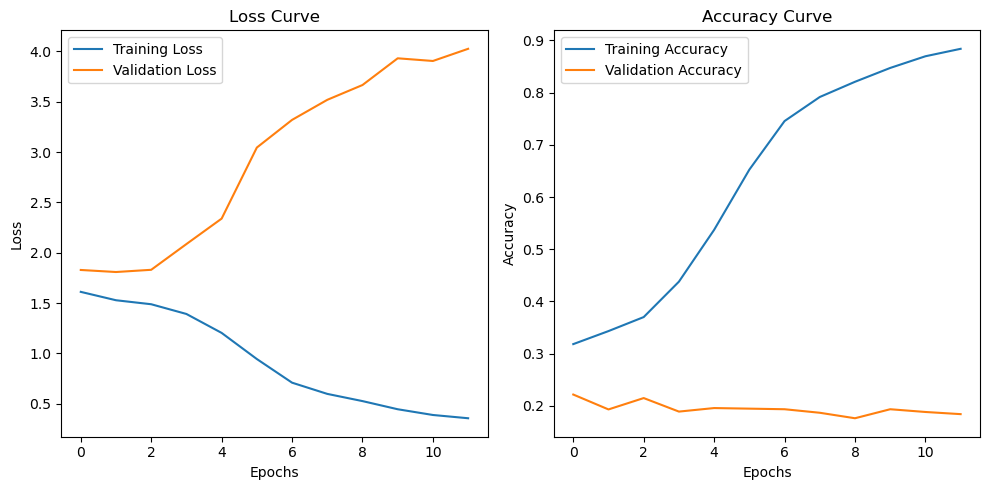

In [21]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig('training_history.png', dpi=300)
plt.show()

## 7. Evaluation & Confusion Matrix (For Chapter 4.2.3)
Testing the model on unseen data and plotting a confusion matrix to show exactly which crops the model predicts correctly.

89/89 [==============================] - 2s 11ms/step
Majority-class baseline: 17.09%
Test accuracy:          45.57%
Balanced accuracy:      39.70%
Macro F1:               0.356
Top-2 accuracy:         60.09%

Classification Report:
              precision    recall  f1-score   support

     Cassava       1.00      1.00      1.00       461
       Maize       0.00      0.00      0.00         5
      Potato       0.19      0.26      0.22       482
        Rice       0.94      1.00      0.97       461
   Sugarcane       0.00      0.00      0.00       470
      Tomato       0.22      0.52      0.31       479
       Wheat       0.00      0.00      0.00       486

    accuracy                           0.46      2844
   macro avg       0.33      0.40      0.36      2844
weighted avg       0.38      0.46      0.41      2844



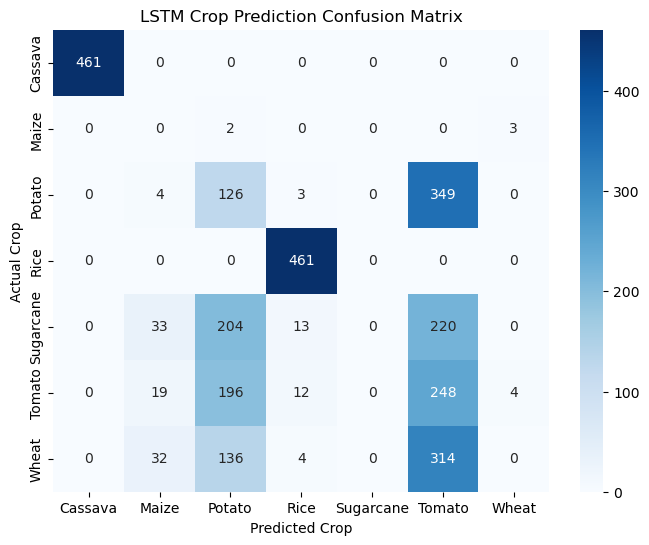

In [22]:
# Evaluate on test set
loss, accuracy, top_2_accuracy = model.evaluate(X_test, y_test, verbose=0)

# Get predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
majority_baseline = np.bincount(y_test).max() / len(y_test)
balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

print(f'Majority-class baseline: {majority_baseline * 100:.2f}%')
print(f'Test accuracy:          {accuracy * 100:.2f}%')
print(f'Balanced accuracy:      {balanced_accuracy * 100:.2f}%')
print(f'Macro F1:               {macro_f1:.3f}')
print(f'Top-2 accuracy:         {top_2_accuracy * 100:.2f}%')

print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    labels=np.arange(NUM_CLASSES),
    target_names=label_encoder.classes_,
    zero_division=0,
))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=np.arange(NUM_CLASSES))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('LSTM Crop Prediction Confusion Matrix')
plt.xlabel('Predicted Crop')
plt.ylabel('Actual Crop')
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

## 8. Save Model & Preprocessors for Backend Integration
Exporting the model weights and data scaler so the FastAPI backend can load them for live inference.

In [23]:
import os
model_dir = os.path.join("backend", "ml")
os.makedirs(model_dir, exist_ok=True)

model.save(os.path.join(model_dir, "lstm_crop_model.keras"))
joblib.dump(imputer, os.path.join(model_dir, "imputer_crop.pkl"))
joblib.dump(scaler, os.path.join(model_dir, "scaler_crop.pkl"))

# Save the label mapping as JSON
label_map = {int(i): str(c) for i, c in enumerate(label_encoder.classes_)}
with open(os.path.join(model_dir, "crop_labels.json"), "w") as f:
    json.dump(label_map, f)

print("Model, imputer, scaler, and labels successfully exported to backend/ml/")

Model, imputer, scaler, and labels successfully exported to backend/ml/
